## Project 1

The goal of the first project is to do some wrangling, EDA, and visualization, and generate sequences of values. We will focus on:

- CDC National Health and Nutritional Examination Survey (NHANES, 1999-2000): https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?BeginYear=1999
- CDC Linked Mortality File (LMF, 1999-2000): https://www.cdc.gov/nchs/data-linkage/mortality-public.htm

NHANES is a rich panel dataset on health and behavior, collected bi-yearly from around 1999 to now. We will focus on the 1999 wave, because that has the largest follow-up window, providing us with the richest mortality data. The mortality data is provided by the CDC Linked Mortality File.

The purpose of the project is to use $k$-NN to predict who dies (hard or soft classification) and how long they live (regression).

### Part 1: Wrangling and EDA (40/100 pts)

First, go to the NHANES and LMF web sites and familiarize yourself with the data sources. Download codebooks. Think about what resources are available. The CDC Linked Mortality File is somewhat of a pain to work with, so I have pre-cleaned it for you. It is available at httts://github.com/ds4e/undergraduate_ml_assignments in the data folder, as `lmf_parsed.cav`. From the CDC LMF web page, get the SAS program to load the data; it is the real codebook.

Second, download the demographic data for the 1999--2000 wave from the NHANES page. You can use the following code chunk to merge the LMF and DEMO data:

``` python
import pandas as pd
mdf = pd.read_csv('linked_mortality_file_1999_2000.csv') # Load mortality file
print( mdf.head() )
gdf = pd.read_sas("DEMO.xpt", format="xport") # Load demographics file
print( gdf.head() )
df = gdf.merge(mdf, on="SEQN", how="inner") # Merge mortality and demographics on SEQN variable
```

Third, the variables `ELIGSTAT`, `MORTSTAT`, `PERMTH_INT`, and `RIDAGEEX` are particularly important. Look them up in the documentation and clearly describe them. (5/100 pts.)

Second, the goal of the project is to use whatever demographic, behavioral, and health data you like to predict mortality (`MORTSTAT`) and life expectancy (`PERMTH_INT`). Go to the NHANES 1999--2000 web page and select your data and download it. Clearly explain your rationale for selecting these data. Use `.merge` to combine your data into one complete dataframe. Document missing values. (5/100 pts)

Third, do basic EDA and visualization of the key variables. Are any important variables skewed? Are there outliers? How correlated are pairs of variables? Do pairs of categorical variables exhibit interesting patterns in contingency tables? Provide a clear discussion and examination of the data and the variables you are interested in using. (20/100 pts)


### Part 2: $k$-NN classification/regression, write-up (50/100 pts)

Submit a notebook that clearly addresses the following, using code and markdown chunks:

1. Describe the data, particularly what an observation is and whether there are any missing data that might impact your analysis. Who collected the data and why? What known limitations are there to analysis? (10/100 pts)
2. Describe the variables you selected to predict mortality and life expectancy, and the rationale behind them. Analyze your variables using describe tables, kernel densities, scatter plots, and conditional kernel densities. Are there any patterns of interest to notice? (10/100 pts)
3. Using your variables to predict mortality using a $k$-Nearest Neighbor Classifier. Analyze its performance and explain clearly how you select $k$. (10/100 pts)
4. Using your variables to predict life expectancy using a $k$-Nearest Neighbor Regressor. Analyze its performance and explain clearly how you select $k$. (10/100 pts)
5. Describe how your model could be used for health interventions based on patient characteristics. Are there any limitations or risks to consider? (10/100 pts)

## Submission (10/100 pts)

Submit your work in a well-organized GitHub repo, where the code is appropriately commented and all members of the group have made significant contributions to the commit history. (10/100 pts)

In [1]:
!git clone https://github.com/ds4e/undergrad_ml_assignments.git
!ls undergrad_ml_assignments/data

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 49, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 49 (delta 14), reused 5 (delta 5), pack-reused 29 (from 2)
Receiving objects: 100% (49/49), 8.58 MiB | 12.57 MiB/s, done.
Resolving deltas: 100% (17/17), done.
DEMO.xpt
linked_mortality_file_1999_2000.csv
public-use-linked-mortality-file-description.pdf
SAS_ReadInProgramAllSurveys.sas


In [5]:
import pandas as pd

mdf = pd.read_csv("undergrad_ml_assignments/data/linked_mortality_file_1999_2000.csv")
gdf = pd.read_sas("undergrad_ml_assignments/data/DEMO.xpt", format="xport")

df = gdf.merge(mdf, on="SEQN", how="inner")
print("Merged shape:", df.shape)
df.head()

Merged shape: (9965, 151)


,SEQN,SDDSRVYR,RIDSTATR,RIDEXMON,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDAGEEX,RIDRETH1,RIDRETH2,...,WTIREP50,WTIREP51,WTIREP52,ELIGSTAT,MORTSTAT,UCOD_LEADING,DIABETES,HYPERTEN,PERMTH_INT,PERMTH_EXM
0,1.0,1.0,2.0,2.0,2.0,2.0,29.0,31.0,4.0,2.0,...,10327.992682,9809.165049,10323.315747,2,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,1.0,2.0,2.0,1.0,77.0,926.0,926.0,3.0,1.0,...,27268.025234,27406.383620,26984.812909,1,1.0,6.0,0.0,0.0,177.0,177.0
2,3.0,1.0,2.0,1.0,2.0,10.0,125.0,126.0,3.0,1.0,...,44480.987235,45389.112766,43781.905637,2,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,1.0,2.0,2.0,1.0,1.0,22.0,23.0,4.0,2.0,...,10851.024385,10564.981435,11012.529729,2,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,1.0,2.0,2.0,1.0,49.0,597.0,597.0,3.0,1.0,...,92817.926915,94282.855382,91993.251203,1,0.0,NaN,NaN,NaN,244.0,244.0


**Variable Description:**

1. ELIGSTAT (Eligibility Status for Mortality Follow-up):
This variable indicates whether a survey participant is eligible to be linked to the National Death Index (NDI) for mortality follow-up. The codebook values are: 1 = Eligible, 2 = Under age 18 (not available for public release), and 3 = Ineligible

2. MORTSTAT (Final Mortality Status):
This is the final determination of whether the participant died during the follow-up period and is the main mortality outcome variable. The codebook values are: 0 = Assumed alive, 1 = Assumed deceased, and “.” for ineligible or under age 18.

3. PERMTH_INT (Number of Person-Months of Follow-up from NHANES interview date):
This variable measures the length of follow-up time (in months) starting from the participant’s NHANES interview date. It ranges from 0 to 374 months in the codebook. Participants who are assumed alive are assigned follow-up months through the end of the mortality follow-up period, while deceased participants have follow-up months up to their death time. Missing/“.” indicates ineligible or under age 18. This is a natural target for a regression model predicting “how long” someone is observed/alive in follow-up.

4. RIDAGEEX (Exam Age in Months – Recode):
This is the participant’s age in months at the Mobile Examination Center (MEC) exam date, reported for individuals under 85 years old at screening (RIDAGEYR < 85). The codebook shows a range of 0 to 1019 months (0–84 years), and it is missing for some participants (e.g., those with imputed age). This variable is a key predictor because age is strongly related to both mortality risk (MORTSTAT) and follow-up time (PERMTH_INT).

**In more simpler terms:** ELIGSTAT = can we track them, MORTSTAT = dead or alive, PERMTH_INT = how many months observed, RIDAGEEX = age at exam.

**Rationale for Choosing These Data**

I use NHANES variables because basic demographics and socioeconomic status would be strong predicters of mortality and survival time. Age (RIDAGEEX), sex (RIAGENDR), and race/ethnicity (RIDRETH1) capture major baseline health differences, while education (DMDEDUC2), income/poverty (INDHHINC, INDFMPIR), marital status (DMDMARTL), household size (DMDHHSIZ), veteran status (DMQMILIT), and country of birth (DMDBORN) proxy for resources, support, and access to care. I merge these predictors to mortality outcomes (MORTSTAT, PERMTH_INT) using SEQN and then quantify missingness to decide what filtering or imputation is needed.

In [6]:
outcomes = ["ELIGSTAT", "MORTSTAT", "PERMTH_INT"]
predictors = [
    "RIDAGEEX", "RIAGENDR", "RIDRETH1",
    "DMDEDUC2", "INDFMPIR", "INDHHINC",
    "DMDMARTL", "DMDHHSIZ", "DMQMILIT", "DMDBORN"
]

keep_cols = ["SEQN"] + outcomes + predictors
df_model = df[keep_cols].copy()

df_model.head()

,SEQN,ELIGSTAT,MORTSTAT,PERMTH_INT,RIDAGEEX,RIAGENDR,RIDRETH1,DMDEDUC2,INDFMPIR,INDHHINC,DMDMARTL,DMDHHSIZ,DMQMILIT,DMDBORN
0,1.0,2,NaN,NaN,31.0,2.0,4.0,NaN,0.86,3.0,NaN,3.0,NaN,1.0
1,2.0,1,1.0,177.0,926.0,1.0,3.0,5.0,5.00,8.0,NaN,1.0,1.0,1.0
2,3.0,2,NaN,NaN,126.0,2.0,3.0,NaN,1.47,6.0,NaN,4.0,NaN,3.0
3,4.0,2,NaN,NaN,23.0,1.0,4.0,NaN,0.57,3.0,NaN,7.0,NaN,1.0
4,5.0,1,0.0,244.0,597.0,1.0,3.0,5.0,5.00,11.0,1.0,3.0,1.0,1.0


In [7]:
#missing values
miss = pd.DataFrame({
    "missing_count": df_model.isna().sum(),
    "missing_pct": (df_model.isna().mean() * 100).round(2)
}).sort_values("missing_pct", ascending=False)

miss

,missing_count,missing_pct
DMDEDUC2,5087,51.05
PERMTH_INT,4520,45.36
MORTSTAT,4520,45.36
DMQMILIT,4234,42.49
DMDMARTL,3893,39.07
INDHHINC,1518,15.23
INDFMPIR,1483,14.88
RIDAGEEX,824,8.27
DMDBORN,11,0.11
SEQN,0,0.00


In [14]:
df_elig = df_model[df_model["ELIGSTAT"] == 1].copy()

print("Eligible sample shape:", df_elig.shape)
print(df_elig[["MORTSTAT","PERMTH_INT"]].isna().mean())

Eligible sample shape: (5445, 14)
MORTSTAT      0.0
PERMTH_INT    0.0
dtype: float64


In [15]:
#EDA & Visualizations
num_vars = ["PERMTH_INT", "RIDAGEEX", "INDFMPIR", "INDHHINC", "DMDHHSIZ"]
df_elig[num_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
PERMTH_INT,5445.0,202.314601,67.137767,0.000000e+00,194.00,235.00,242.0000,250.0
RIDAGEEX,4840.0,553.576240,235.457568,2.160000e+02,343.75,530.00,758.0000,1019.0
INDFMPIR,4604.0,2.436670,1.607523,5.397605e-79,1.07,2.04,3.8725,5.0
INDHHINC,4583.0,7.373773,8.466623,1.000000e+00,4.00,6.00,9.5000,99.0
DMDHHSIZ,5445.0,3.214509,1.722877,1.000000e+00,2.00,3.00,4.0000,7.0


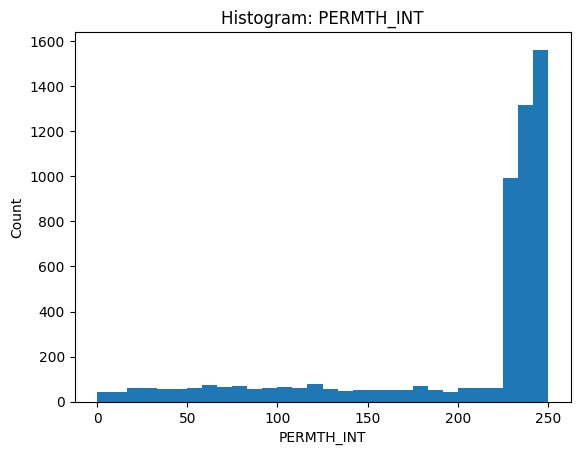

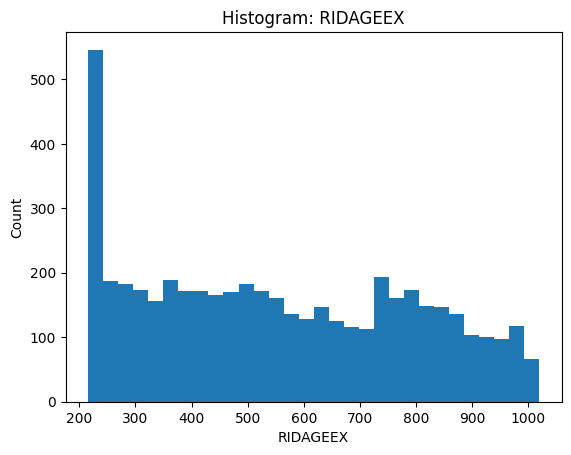

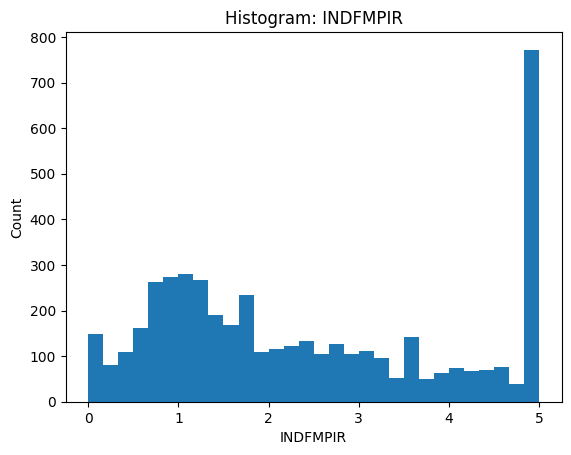

In [16]:
import matplotlib.pyplot as plt

for v in ["PERMTH_INT","RIDAGEEX","INDFMPIR"]:
    plt.figure()
    plt.hist(df_elig[v].dropna(), bins=30)
    plt.title(f"Histogram: {v}")
    plt.xlabel(v)
    plt.ylabel("Count")
    plt.show()

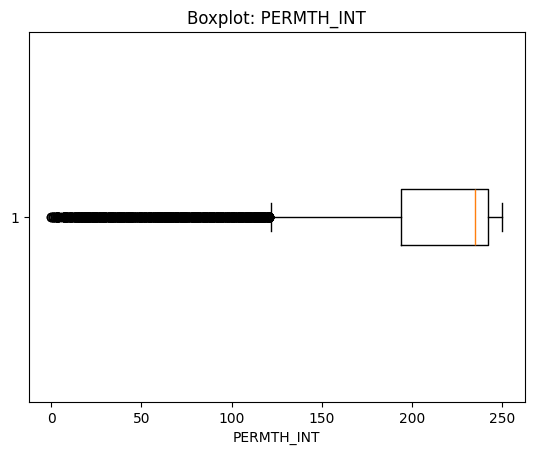

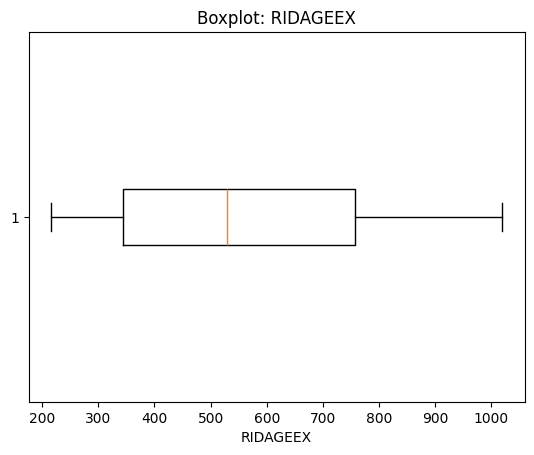

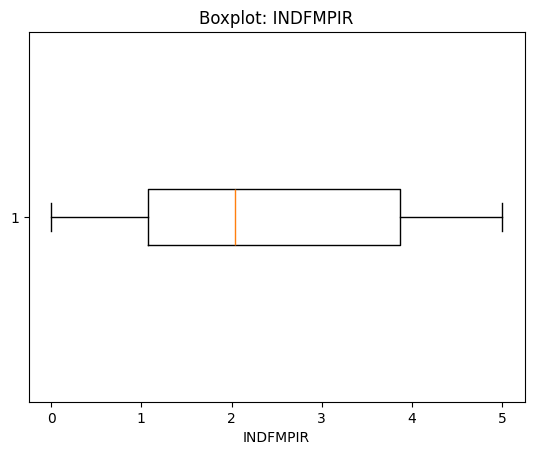

In [17]:
for v in ["PERMTH_INT","RIDAGEEX","INDFMPIR"]:
    plt.figure()
    plt.boxplot(df_elig[v].dropna(), vert=False)
    plt.title(f"Boxplot: {v}")
    plt.xlabel(v)
    plt.show()

In [18]:
corr_vars = ["PERMTH_INT","RIDAGEEX","INDFMPIR","INDHHINC","DMDHHSIZ"]
df_elig[corr_vars].corr()

,PERMTH_INT,RIDAGEEX,INDFMPIR,INDHHINC,DMDHHSIZ
PERMTH_INT,1.000000,-0.558842,0.109559,0.068349,0.274871
RIDAGEEX,-0.558842,1.000000,0.062281,-0.071749,-0.409216
INDFMPIR,0.109559,0.062281,1.000000,0.803589,-0.189255
INDHHINC,0.068349,-0.071749,0.803589,1.000000,0.133874
DMDHHSIZ,0.274871,-0.409216,-0.189255,0.133874,1.000000


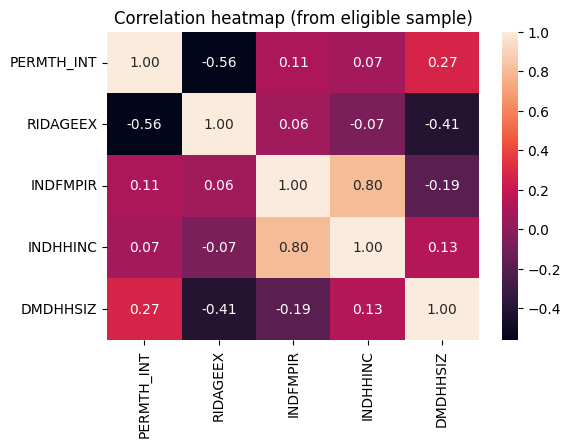

In [21]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(df_elig[corr_vars].corr(), annot=True, fmt=".2f")
plt.title("Correlation heatmap (from eligible sample)")
plt.show()

In [22]:
cat_vars = ["RIAGENDR","RIDRETH1","DMDEDUC2","DMDMARTL","DMDBORN","DMQMILIT"]

for v in cat_vars:
    tab = pd.crosstab(df_elig[v], df_elig["MORTSTAT"], normalize="index")
    print("\nMortality rate by", v)
    print(tab)


Mortality rate by RIAGENDR
MORTSTAT       0.0       1.0
RIAGENDR                    
1.0       0.653454  0.346546
2.0       0.726614  0.273386

Mortality rate by RIDRETH1
MORTSTAT       0.0       1.0
RIDRETH1                    
1.0       0.764023  0.235977
2.0       0.783383  0.216617
3.0       0.626020  0.373980
4.0       0.690821  0.309179
5.0       0.766839  0.233161

Mortality rate by DMDEDUC2
MORTSTAT       0.0       1.0
DMDEDUC2                    
1.0       0.496781  0.503219
2.0       0.626556  0.373444
3.0       0.667883  0.332117
4.0       0.735267  0.264733
5.0       0.784091  0.215909
7.0       0.250000  0.750000
9.0       0.428571  0.571429

Mortality rate by DMDMARTL
MORTSTAT       0.0       1.0
DMDMARTL                    
1.0       0.670850  0.329150
2.0       0.229474  0.770526
3.0       0.632979  0.367021
4.0       0.785311  0.214689
5.0       0.907838  0.092162
6.0       0.837104  0.162896
77.0      0.142857  0.857143
99.0      1.000000  0.000000

Mortality rate by

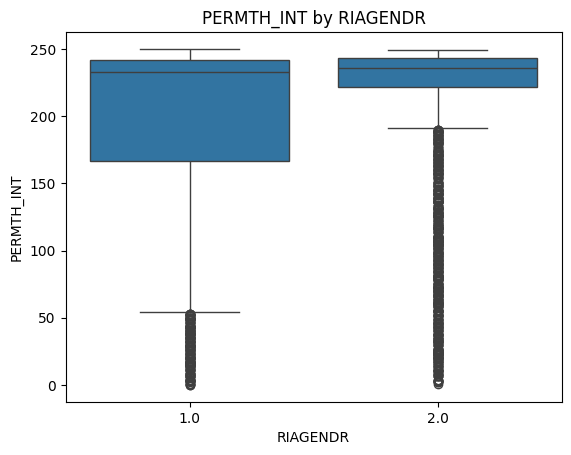

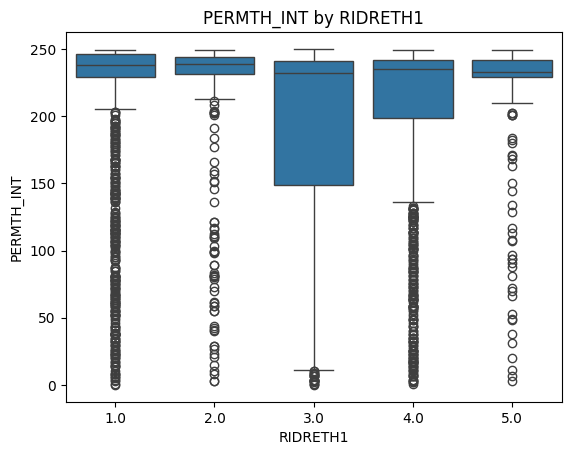

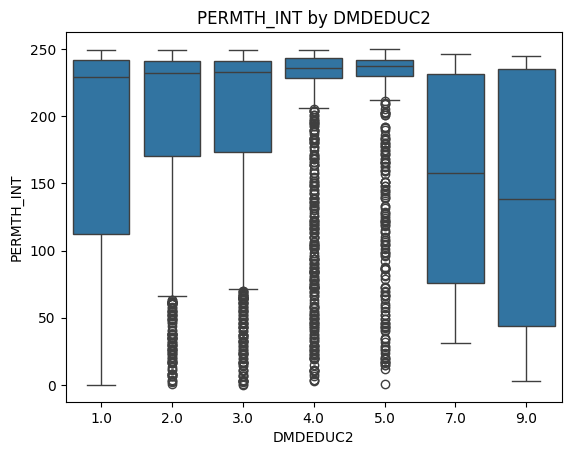

In [23]:
for v in ["RIAGENDR","RIDRETH1","DMDEDUC2"]:
    plt.figure()
    sns.boxplot(data=df_elig, x=v, y="PERMTH_INT")
    plt.title(f"PERMTH_INT by {v}")
    plt.show()

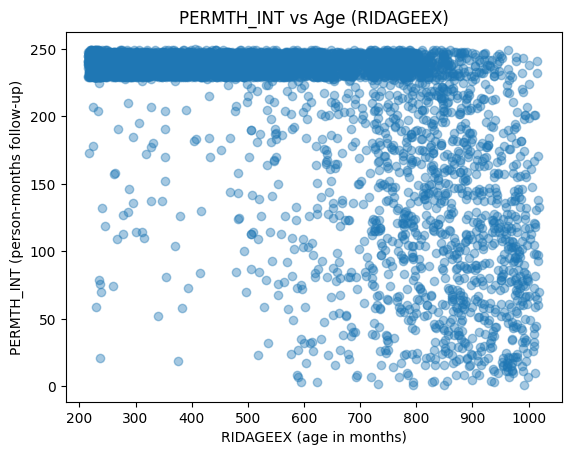

In [24]:
plt.figure()
plt.scatter(df_elig["RIDAGEEX"], df_elig["PERMTH_INT"], alpha=0.4)
plt.xlabel("RIDAGEEX (age in months)")
plt.ylabel("PERMTH_INT (person-months follow-up)")
plt.title("PERMTH_INT vs Age (RIDAGEEX)")
plt.show()

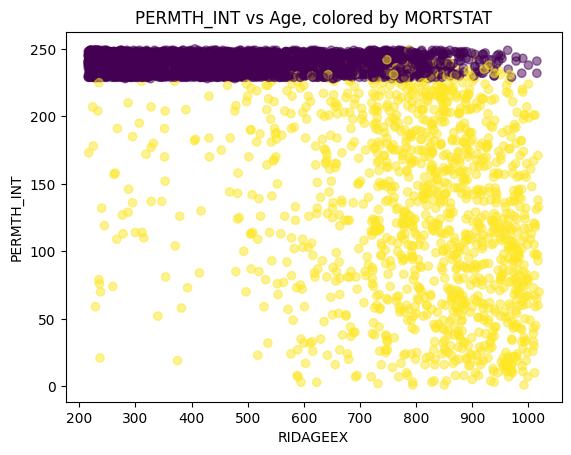

In [25]:
plt.figure()
plt.scatter(df_elig["RIDAGEEX"], df_elig["PERMTH_INT"], c=df_elig["MORTSTAT"], alpha=0.5)
plt.xlabel("RIDAGEEX")
plt.ylabel("PERMTH_INT")
plt.title("PERMTH_INT vs Age, colored by MORTSTAT")
plt.show()